正在读取全市场数据，请稍候...
正在过滤沪深主板数据...
开始执行策略：市值最小50只中选股价最低的10只...

✅ 结果分析:
💰 最终总资产: 845,405.16 元
📈 策略总收益率: 1590.81%


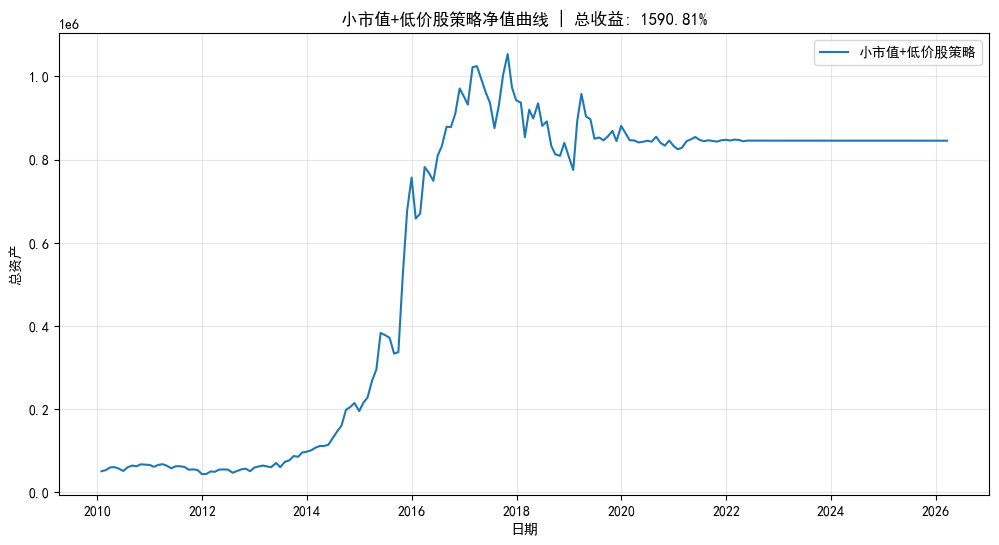

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置参数与读取数据
# ==========================================
FILE_PATH = r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\quant\小市值低价策略交易明细.xlsx"

INITIAL_CASH = 50000.0  # 初始本金 5万元
TARGET_STOCK_NUM = 10   # 目标持仓 10 只
POOL_SIZE = 50          # 第一步筛选的市值最小股票池数量

print("正在读取全市场数据，请稍候...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])

# 过滤沪深主板股票 (上交所 60 开头，深交所 00 开头)
print("正在过滤沪深主板数据...")
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask].copy()

# 按照日期和代码排序
df.sort_values(by=['date', 'code'], inplace=True)

# 提取每个月的最后一个交易日作为调仓日
df['year_month'] = df['date'].dt.to_period('M')
trade_dates = df.groupby('year_month')['date'].max().sort_values().tolist()

# ==========================================
# 第二步：定义交易费率计算函数
# ==========================================
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    # 1. 佣金 (最低5元)
    commission = max(5.0, amount * 0.00025)
    # 2. 过户费
    transfer_fee = amount * 0.00001
    # 3. 印花税 (仅卖出收取)
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0

    total_fee = commission + transfer_fee + stamp_duty
    return total_fee, amount

# ==========================================
# 第三步：账户类与回测主引擎
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}  # {code: {'volume': 股数, 'price': 最新价}}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_date, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            price = current_prices_dict.get(code, pos['price'])
            self.positions[code]['price'] = price
            stock_value += pos['volume'] * price
        return self.cash + stock_value

account = Account(INITIAL_CASH)

print(f"开始执行策略：市值最小{POOL_SIZE}只中选股价最低的{TARGET_STOCK_NUM}只...")

for date in trade_dates:
    daily_data = df[df['date'] == date].set_index('code')
    current_prices = daily_data['close'].to_dict()

    status_dict = daily_data['tradestatus'].to_dict()
    st_dict = daily_data['isST'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(date, current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 核心选股逻辑修改 ----------------
    # 1. 基础过滤：正常交易、非ST
    # 注意：低价股策略通常不限制 PE > 0，因为很多低价股可能是困境反转股
    valid_pool = daily_data[(daily_data['tradestatus'] == 1) &
                            (daily_data['isST'] == 0)].copy()

    target_codes = []
    if len(valid_pool) >= POOL_SIZE:
        # 第一步：按流通市值升序排列，取前 50 只
        smallest_50 = valid_pool.sort_values(by='流通市值', ascending=True).head(POOL_SIZE)

        # 第二步：在市值最小的 50 只中，按股价（close）升序排列，取前 10 只
        target_codes = smallest_50.sort_values(by='close', ascending=True).head(TARGET_STOCK_NUM).index.tolist()
    # ------------------------------------------------

    # ---------------- 卖出逻辑 ----------------
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            # 卖出约束：正常交易且未封死跌停
            if is_trading and pct_chg > -9.3:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)

                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2),
                    '总资产': round(account.get_total_asset(date, current_prices), 2),
                    '备注': '调仓卖出'
                })
            elif pct_chg <= -9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出失败(跌停)',
                    '成交价': 0, '成交股数': 0, '备注': '封死跌停无法卖出'
                })

    # ---------------- 买入逻辑 ----------------
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    if len(stocks_to_buy) > 0:
        # 现金平摊到每个需要购买的席位
        target_cash_per_stock = account.cash / len(stocks_to_buy)

        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)

            # 买入约束：正常交易、且不能涨停
            if is_trading and pct_chg < 9.3:
                buy_price = current_prices[code]
                # 预留0.3%费率空间并向下取整百股
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2),
                            '总资产': round(account.get_total_asset(date, current_prices), 2),
                            '备注': '正常买入'
                        })
            elif pct_chg >= 9.3:
                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '买入失败(涨停)',
                    '成交价': 0, '成交股数': 0, '备注': '涨停无法买入'
                })

# ==========================================
# 第四步：输出结果与可视化
# ==========================================
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)

df_assets = pd.DataFrame(account.history_assets)
df_assets.set_index('date', inplace=True)
final_asset = df_assets['total_asset'].iloc[-1]
total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

print(f"\n✅ 结果分析:")
print(f"💰 最终总资产: {final_asset:,.2f} 元")
print(f"📈 策略总收益率: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_assets.index, df_assets['total_asset'], label='小市值+低价股策略')
plt.title(f'小市值+低价股策略净值曲线 | 总收益: {total_return:.2f}%')
plt.xlabel('日期')
plt.ylabel('总资产')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()